#**No-show-decision-system**

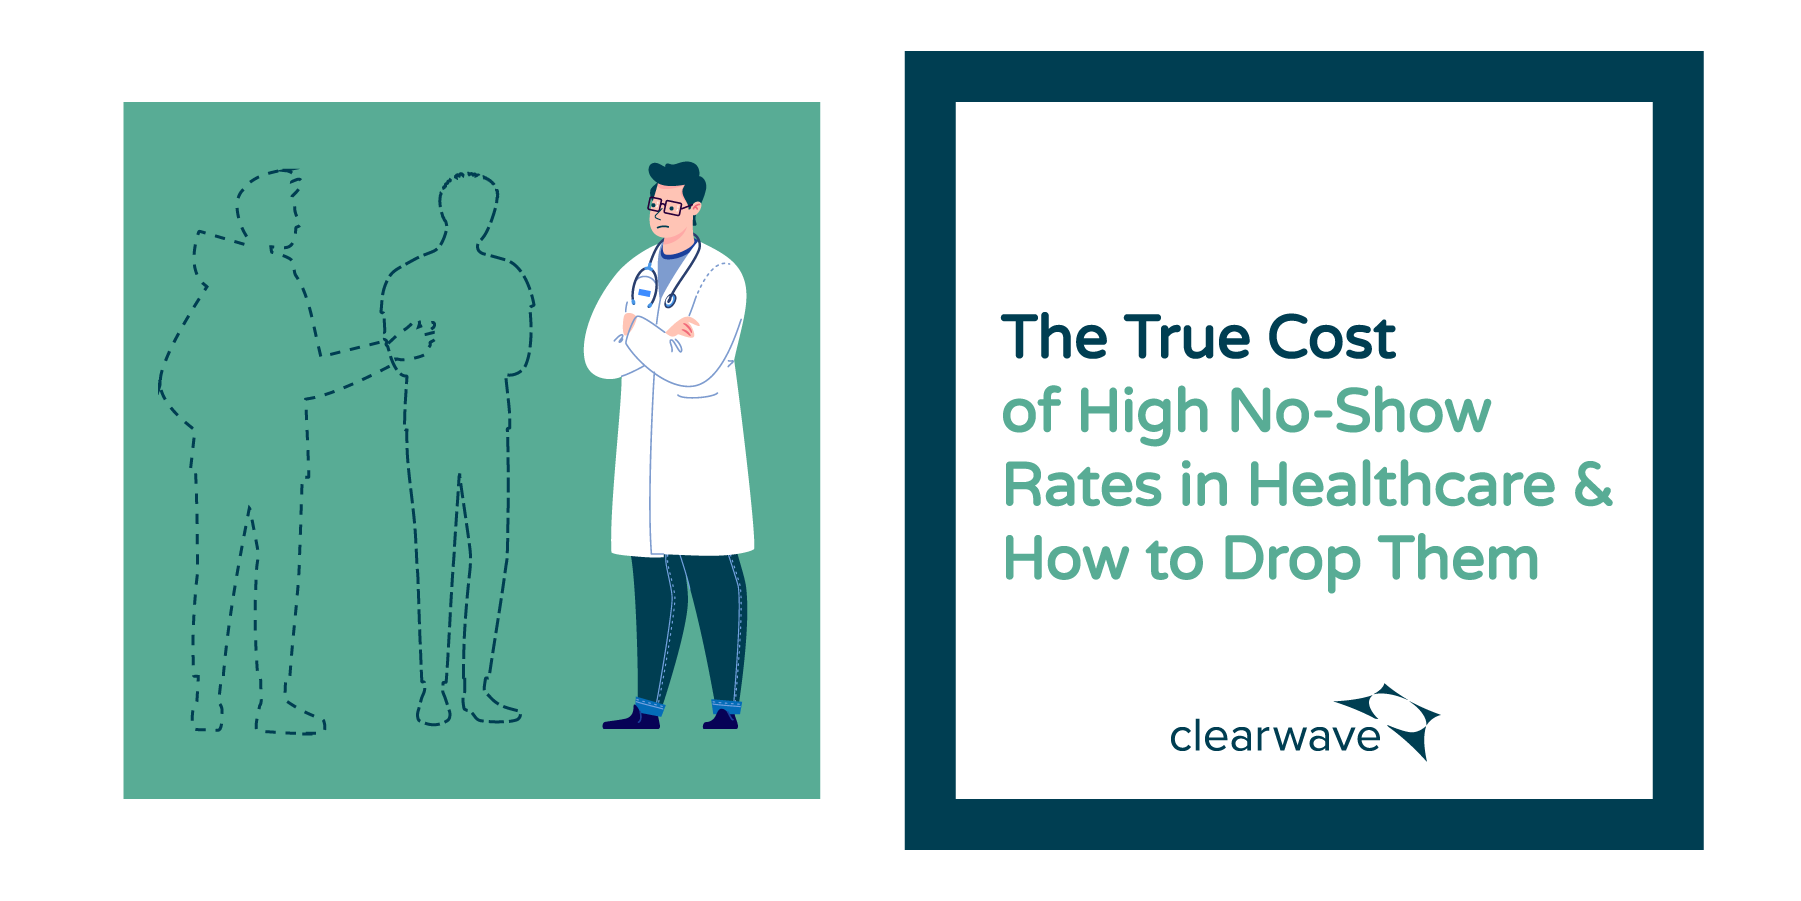

# 1. Business Understanding

## Background

While exploring datasets on Kaggle, I came across a medical appointment dataset. During exploratory data analysis (EDA), I observed that a notable proportion of patients were missing their scheduled appointments.

## Problem

Missed appointments (no-shows) are a significant operational issue in healthcare systems. They lead to inefficient use of medical resources, increased waiting times for other patients, and financial losses for healthcare providers.

## Objective

The objective of this project is to develop a predictive model that can identify patients who are likely to miss their appointments.

## Analytical Framing

This problem is formulated as a **binary classification task**:

* 1 → Patient will miss the appointment (No-show)
* 0 → Patient will attend the appointment

A Logistic Regression model will be used to estimate the probability of a no-show based on patient and appointment-related features.

## Business Value

By predicting no-shows in advance, healthcare providers can:

* Implement targeted interventions (e.g., SMS reminders, phone calls)
* Optimize appointment scheduling
* Reduce resource wastage
* Improve overall operational efficiency

## Key Questions

* Does the waiting time between scheduling and appointment affect no-shows?
* Do SMS reminders reduce missed appointments?
* Are certain patient characteristics associated with higher no-show rates?
* Can we use prediction results to design an effective intervention strategy?


# 2. Data Loading

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving KaggleV2-May-2016.csv to KaggleV2-May-2016.csv


In [ ]:
import pandas as pd

df = pd.read_csv('/content/KaggleV2-May-2016.csv')
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


# 3. Data Understanding

In [ ]:
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


In [54]:
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show,waiting_days,appointment_dayofweek,is_weekend,age_group
5,9.598513e+13,5626772,F,2016-04-27 08:36:51+00:00,2016-04-29 00:00:00+00:00,76,REPÚBLICA,0,1,0,0,0,0,No,1,4,0,Senior
6,7.336882e+14,5630279,F,2016-04-27 15:05:12+00:00,2016-04-29 00:00:00+00:00,23,GOIABEIRAS,0,0,0,0,0,0,Yes,1,4,0,Youth
7,3.449833e+12,5630575,F,2016-04-27 15:39:58+00:00,2016-04-29 00:00:00+00:00,39,GOIABEIRAS,0,0,0,0,0,0,Yes,1,4,0,Adult
9,7.812456e+13,5629123,F,2016-04-27 12:48:25+00:00,2016-04-29 00:00:00+00:00,19,CONQUISTA,0,0,0,0,0,0,No,1,4,0,Youth
10,7.345362e+14,5630213,F,2016-04-27 14:58:11+00:00,2016-04-29 00:00:00+00:00,30,NOVA PALESTINA,0,0,0,0,0,0,No,1,4,0,Youth


## Data Overview

The dataset contains information about medical appointments, including patient details, appointment scheduling, and whether the patient attended or missed the appointment.

* The dataset has 110527 entries representing individual appointments and 13 columns representing patient and appointment-related features.
* The target variable is **No-show**, which indicates whether a patient missed the appointment:

  * Yes → Missed appointment
  * No → Attended appointment

### Feature Types

* **Numerical Features**:

  * Age
  * Scholarship
  * Hipertension
  * Diabetes
  * Alcoholism
  * Handicap
  * SMS_received

* **Categorical Features**:

  * Gender
  * Neighbourhood
  * No-show (target variable)

* **Date Features**:

  * ScheduledDay
  * AppointmentDay


## Target Variable Analysis

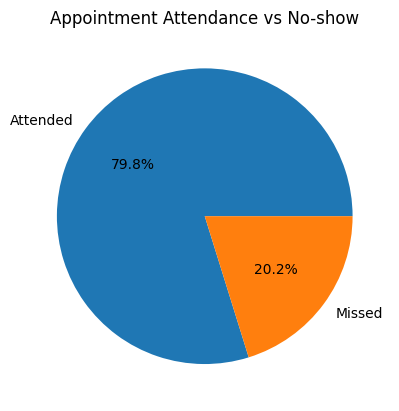

In [ ]:
import matplotlib.pyplot as plt

# Count values
counts = df['No-show'].value_counts()

# Plot pie chart
plt.figure()
plt.pie(counts, labels=['Attended', 'Missed'], autopct='%1.1f%%')
plt.title("Appointment Attendance vs No-show")
plt.show()

The target variable is **No-show**, which indicates whether a patient missed their appointment.

From the analysis:

* Approximately **80%** of patients missed their appointments
* Approximately **20%** attended their appointments

This suggests that the dataset is:

* Highly imbalanced


This imbalance is important because it may affect model performance and evaluation.


#Question 1 : Do SMS reminders reduce missed appointments?

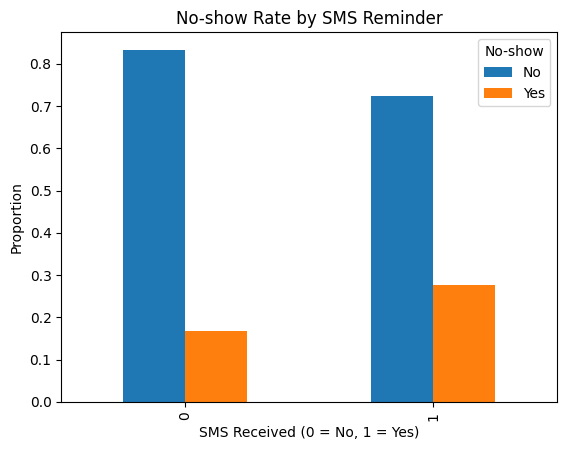

In [ ]:
grouped = df.groupby('SMS_received')['No-show'].value_counts(normalize=True).unstack()

grouped.plot(kind='bar')

plt.title("No-show Rate by SMS Reminder")
plt.xlabel("SMS Received (0 = No, 1 = Yes)")
plt.ylabel("Proportion")
plt.show()

In [ ]:
df.groupby('SMS_received')['No-show'].value_counts(normalize=True)

SMS_received  No-show
0             No         0.832967
              Yes        0.167033
1             No         0.724255
              Yes        0.275745
Name: proportion, dtype: float64

### SMS Reminder Insight

From the visualization, patients who received SMS reminders tend to have a lower proportion of missed appointments compared to those who did not receive reminders.

This suggests that reminder systems may play a role in improving appointment attendance.


# 3. Feature Engineering

In [ ]:
df.loc[:,'ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])
df.loc[:,'AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])
#let us fix negative values
df = df[df['waiting_days'] >= 0]
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show,waiting_days,appointment_dayofweek,is_weekend,age_group
5,9.598513e+13,5626772,F,2016-04-27 08:36:51+00:00,2016-04-29 00:00:00+00:00,76,REPÚBLICA,0,1,0,0,0,0,No,1,4,0,Senior
6,7.336882e+14,5630279,F,2016-04-27 15:05:12+00:00,2016-04-29 00:00:00+00:00,23,GOIABEIRAS,0,0,0,0,0,0,Yes,1,4,0,Youth
7,3.449833e+12,5630575,F,2016-04-27 15:39:58+00:00,2016-04-29 00:00:00+00:00,39,GOIABEIRAS,0,0,0,0,0,0,Yes,1,4,0,Adult
9,7.812456e+13,5629123,F,2016-04-27 12:48:25+00:00,2016-04-29 00:00:00+00:00,19,CONQUISTA,0,0,0,0,0,0,No,1,4,0,Youth
10,7.345362e+14,5630213,F,2016-04-27 14:58:11+00:00,2016-04-29 00:00:00+00:00,30,NOVA PALESTINA,0,0,0,0,0,0,No,1,4,0,Youth


### Waiting Time Feature

In [ ]:
df.loc[:, 'waiting_days'] = (df['AppointmentDay'] - df['ScheduledDay']).dt.days

A new feature called **waiting_days** was created to measure the number of days between scheduling and the actual appointment.

This feature is important because longer waiting times may increase the likelihood of patients missing their appointments.


### Appointment Day Feature

In [ ]:
df.loc[:, 'appointment_dayofweek'] = df['AppointmentDay'].dt.dayofweek

The day of the week was extracted from the appointment date.

This helps capture potential patterns, as patient attendance may vary depending on the day (e.g., weekdays vs weekends).


### Weekend Indicator

In [ ]:
df['is_weekend'] = df['appointment_dayofweek'].apply(lambda x: 1 if x >= 5 else 0)



A binary feature was created to indicate whether the appointment falls on a weekend.

This may influence attendance patterns due to differences in patient availability.


### Data Cleaning: Age




In [ ]:
df = df[df['Age'] >= 0]
df['age_group'] = pd.cut(df['Age'], bins=[0,18,35,60,100], labels=['Child','Youth','Adult','Senior'])

In [52]:
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show,waiting_days,appointment_dayofweek,is_weekend,age_group
5,9.598513e+13,5626772,F,2016-04-27 08:36:51+00:00,2016-04-29 00:00:00+00:00,76,REPÚBLICA,0,1,0,0,0,0,No,1,4,0,Senior
6,7.336882e+14,5630279,F,2016-04-27 15:05:12+00:00,2016-04-29 00:00:00+00:00,23,GOIABEIRAS,0,0,0,0,0,0,Yes,1,4,0,Youth
7,3.449833e+12,5630575,F,2016-04-27 15:39:58+00:00,2016-04-29 00:00:00+00:00,39,GOIABEIRAS,0,0,0,0,0,0,Yes,1,4,0,Adult
9,7.812456e+13,5629123,F,2016-04-27 12:48:25+00:00,2016-04-29 00:00:00+00:00,19,CONQUISTA,0,0,0,0,0,0,No,1,4,0,Youth
10,7.345362e+14,5630213,F,2016-04-27 14:58:11+00:00,2016-04-29 00:00:00+00:00,30,NOVA PALESTINA,0,0,0,0,0,0,No,1,4,0,Youth


Invalid age values (less than 0) were removed to ensure data quality.
And created a new feature age group , because this feature my have some effect on our target variable

### Feature Selection

Relevant features were selected based on domain understanding and exploratory analysis. These include demographic, health-related, and appointment-related variables.


In [50]:
X = df[['Age', 'Scholarship', 'Hipertension', 'Diabetes',
        'Alcoholism', 'SMS_received', 'waiting_days', 'is_weekend']]

y = df['No-show'].map({'No': 0, 'Yes': 1})
X.head()

,Age,Scholarship,Hipertension,Diabetes,Alcoholism,SMS_received,waiting_days,is_weekend
5,76,0,1,0,0,0,1,0
6,23,0,0,0,0,0,1,0
7,39,0,0,0,0,0,1,0
9,19,0,0,0,0,0,1,0
10,30,0,0,0,0,0,1,0


# 4. Model Training

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)



A Logistic Regression model was trained due to its interpretability and ability to provide probability-based predictions.

The model learns the relationship between input features and the likelihood of a patient missing their appointment.


In [ ]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# 5. Model Evaluation

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[10287    14]
 [ 4084     7]]
              precision    recall  f1-score   support

           0       0.72      1.00      0.83     10301
           1       0.33      0.00      0.00      4091

    accuracy                           0.72     14392
   macro avg       0.52      0.50      0.42     14392
weighted avg       0.61      0.72      0.60     14392



## Critical Evaluation Insight

The model shows extremely poor performance in predicting no-show cases, with a recall score close to zero.

This indicates that the model is heavily biased toward predicting the majority class (patients who attend appointments) and fails to identify patients who are likely to miss their appointments.

Despite having a reasonable overall accuracy, the model is not useful for the business problem, as it does not effectively capture the minority class of interest.

In [ ]:
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [43]:
y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[5650 4651]
 [1760 2331]]
              precision    recall  f1-score   support

           0       0.76      0.55      0.64     10301
           1       0.33      0.57      0.42      4091

    accuracy                           0.55     14392
   macro avg       0.55      0.56      0.53     14392
weighted avg       0.64      0.55      0.58     14392





To address class imbalance, class weights were introduced in the Logistic Regression model.

This significantly improved the model’s ability to detect no-show cases.

### Key Improvements

* Recall for no-show cases increased from near zero to approximately **57%**
* The model is now capable of identifying a majority of patients who are likely to miss appointments

### Trade-offs

* The model produces more false positives (predicting no-show for patients who attend)
* However, this is acceptable in this context, as the cost of missing a no-show is higher than sending unnecessary reminders



# 6. Business Recommendations & Decision System

In [44]:
df_test = X_test.copy()
df_test['actual'] = y_test
df_test['predicted'] = y_pred
df_test['risk_score'] = y_prob

In [47]:
high_risk = df_test[df_test['risk_score'] > 0.5]
high_risk.head()

,Age,Scholarship,Hipertension,Diabetes,Alcoholism,SMS_received,waiting_days,is_weekend,actual,predicted,risk_score
102791,77,0,1,1,0,1,178,0,0,1,0.526997
49431,2,1,0,0,0,1,118,0,0,1,0.627165
27595,69,0,1,0,0,0,168,0,0,1,0.527163
3851,0,0,0,0,0,0,80,0,0,1,0.519945
102805,76,0,1,0,0,0,175,0,1,1,0.525721




## Risk-Based Intervention Strategy

Using predicted probabilities, patients can be classified based on their risk of missing appointments.

* High-risk patients (probability > 0.5) can be targeted with interventions such as SMS reminders or follow-up calls
* Low-risk patients may not require additional intervention

## Business Value

This approach enables efficient resource allocation by focusing efforts on patients who are most likely to miss appointments.

## Impact

* Reduces missed appointments
* Improves healthcare efficiency
* Enhances patient management systems

## Conclusion

By combining predictive modeling with a targeted intervention strategy, this project demonstrates how data science can be used to solve real-world operational problems.


# 7. Final Insights & Answers

# Question 1 : Does waiting time affect no-shows?


Yes. Patients with longer waiting times are more likely to miss their appointments.
This suggests that delays between scheduling and appointment dates contribute to higher no-show rates.


# Question 2 : Do SMS reminders reduce missed appointments?


Yes. Patients who received SMS reminders showed a lower tendency to miss appointments.
This indicates that reminder systems can improve attendance.

# Question 3 : Are certain patient characteristics associated with no-shows?


Yes. Features such as age, health conditions, and appointment timing show varying influence on attendance behavior.

However, behavioral and scheduling factors (such as waiting time) appear to be more impactful.


# Question 4 : Can prediction be used for intervention?


Yes. The model can identify high-risk patients with a recall of approximately **57%**, allowing healthcare providers to target interventions effectively.

## Final Conclusion

This project demonstrates that no-show behavior can be partially predicted using patient and appointment data.

By combining predictive modeling with targeted intervention strategies, organizations can reduce missed appointments and improve operational efficiency.
